# Burnout Prediction Model - FIXED VERSION
Dengan proper validation testing menggunakan 100 samples random yang BELUM pernah dilihat model

## 1. Library

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
import joblib
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

print("All libraries loaded successfully!")

All libraries loaded successfully!


## 2. Load Data

In [2]:
# Load original data
df = pd.read_csv(r'C:\Users\Pongo\Desktop\DBS project\LowCortisol\DataScientist\dataAI_cleaned.csv')

print(f"Original dataset shape: {df.shape}")
print(f"Target distribution:")
print(df['tingkat_burnout'].value_counts().sort_index())

Original dataset shape: (26139, 47)
Target distribution:
tingkat_burnout
0      7379
1     18168
2        83
3       111
4       115
5        75
6        56
7        65
8        39
9        21
10       27
Name: count, dtype: int64


## 3. PENTING: Pisahkan Data SEBELUM Sampling!
**Strategi:**
1. Split 100 data random TERLEBIH DAHULU untuk independent test
2. Sisanya digunakan untuk train + validation
3. Baru kemudian lakukan SMOTE pada train+validation

In [3]:
# STEP 1: Extract 100 samples RANDOM untuk independent test
# Data ini TIDAK AKAN disentuh dalam training
df_independent_test = df.sample(n=100, random_state=42)
df_training = df.drop(df_independent_test.index)  # Sisanya untuk training

print(f"Independent Test Set: {df_independent_test.shape[0]} samples")
print(f"Training Set (akan disampling): {df_training.shape[0]} samples")

print(f"\nIndependent Test Set - Burnout Distribution:")
print(df_independent_test['tingkat_burnout'].value_counts().sort_index())

print(f"\nTraining Set - Burnout Distribution:")
print(df_training['tingkat_burnout'].value_counts().sort_index())

Independent Test Set: 100 samples
Training Set (akan disampling): 26039 samples

Independent Test Set - Burnout Distribution:
tingkat_burnout
0    17
1    82
3     1
Name: count, dtype: int64

Training Set - Burnout Distribution:
tingkat_burnout
0      7362
1     18086
2        83
3       110
4       115
5        75
6        56
7        65
8        39
9        21
10       27
Name: count, dtype: int64


## 4. Encoding Kolom Kategorikal (Hanya pada Training Data)

In [4]:
# Pisahkan features dan target untuk training set
X_training = df_training.drop(columns=['tingkat_burnout'])
y_training = df_training['tingkat_burnout']

# Pisahkan features dan target untuk independent test set
X_independent_test = df_independent_test.drop(columns=['tingkat_burnout'])
y_independent_test = df_independent_test['tingkat_burnout']

# PENTING: Encode HANYA berdasarkan training data
# Ini mencegah data leakage
encoders = {}
categorical_cols = X_training.select_dtypes(include=['object']).columns

print(f"Encoding {len(categorical_cols)} categorical columns...")

for col in categorical_cols:
    le = LabelEncoder()
    X_training[col] = le.fit_transform(X_training[col].astype(str))
    encoders[col] = le

# Transform independent test set menggunakan SAME encoders dari training
for col in categorical_cols:
    X_independent_test[col] = encoders[col].transform(X_independent_test[col].astype(str))

print(f"\nEncoding completed!")
print(f"Training features shape: {X_training.shape}")
print(f"Independent test features shape: {X_independent_test.shape}")

joblib.dump(encoders, 'all_encoders.pkl')

Encoding 20 categorical columns...

Encoding completed!
Training features shape: (26039, 46)
Independent test features shape: (100, 46)


C:\Users\Pongo\AppData\Local\Temp\ipykernel_11900\3350303799.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_training.select_dtypes(include=['object']).columns


['all_encoders.pkl']

## 5. Scaling Features

In [5]:
# PENTING: Fit scaler HANYA pada training data
scaler = StandardScaler()
X_training_scaled = scaler.fit_transform(X_training)

# Transform independent test set menggunakan SAME scaler
X_independent_test_scaled = scaler.transform(X_independent_test)

print(f"Training features scaled: {X_training_scaled.shape}")
print(f"Independent test features scaled: {X_independent_test_scaled.shape}")

joblib.dump(scaler, 'scaler.pkl')

Training features scaled: (26039, 46)
Independent test features scaled: (100, 46)


['scaler.pkl']

## 6. Kategorisasi Burnout menjadi 3 Kelas (Low, Moderate, High)

In [6]:
def categorize_burnout(level):
    if level <= 3:
        return 0  # Low
    elif level <= 7:
        return 1  # Moderate
    else:
        return 2  # High

# Kategorisasi training set
y_training_categorized = y_training.apply(categorize_burnout)

# Kategorisasi independent test set
y_independent_test_categorized = y_independent_test.apply(categorize_burnout)

print(f"Training Set - Categorized Distribution:")
print(y_training_categorized.value_counts().sort_index())
print(f"\nIndependent Test Set - Categorized Distribution:")
print(y_independent_test_categorized.value_counts().sort_index())

Training Set - Categorized Distribution:
tingkat_burnout
0    25641
1      311
2       87
Name: count, dtype: int64

Independent Test Set - Categorized Distribution:
tingkat_burnout
0    100
Name: count, dtype: int64


## 7. SMOTE + Under-sampling (HANYA pada Training Set)

In [7]:
# Create hybrid sampling pipeline
under = RandomUnderSampler(sampling_strategy={0: 5000}, random_state=42)
over = SMOTE(sampling_strategy='auto', random_state=42)

steps = [('u', under), ('o', over)]
pipeline = Pipeline(steps=steps)

# PENTING: Apply SMOTE HANYA pada training set
# Independent test set tetap original (tidak di-resample)
X_resampled, y_resampled = pipeline.fit_resample(X_training_scaled, y_training_categorized)

print(f"\n=== RESAMPLING RESULT ===")
print(f"Before resampling: {X_training_scaled.shape[0]} samples")
print(f"After resampling: {X_resampled.shape[0]} samples")
print(f"\nResampled distribution:")
print(pd.Series(y_resampled).value_counts().sort_index())
print(f"\n✓ Data sekarang BALANCED")


=== RESAMPLING RESULT ===
Before resampling: 26039 samples
After resampling: 15000 samples

Resampled distribution:
tingkat_burnout
0    5000
1    5000
2    5000
Name: count, dtype: int64

✓ Data sekarang BALANCED


## 8. Train-Validation Split (Dari Resampled Data)

In [8]:
# Split resampled data into train dan validation
X_train, X_val, y_train, y_val = train_test_split(
    X_resampled, y_resampled,
    test_size=0.2,
    random_state=42,
    stratify=y_resampled
)

print(f"=== TRAIN-VALIDATION SPLIT ===")
print(f"Training set: {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"\nTraining distribution:")
print(pd.Series(y_train).value_counts().sort_index())
print(f"\nValidation distribution:")
print(pd.Series(y_val).value_counts().sort_index())

=== TRAIN-VALIDATION SPLIT ===
Training set: 12000 samples
Validation set: 3000 samples

Training distribution:
tingkat_burnout
0    4000
1    4000
2    4000
Name: count, dtype: int64

Validation distribution:
tingkat_burnout
0    1000
1    1000
2    1000
Name: count, dtype: int64


## 9. Summary: 3 Dataset yang Terpisah

In [9]:
print("\n" + "="*60)
print("SUMMARY: 3 INDEPENDENT DATASETS")
print("="*60)

print(f"\n1. TRAINING SET (digunakan untuk training):")
print(f"   - Samples: {X_train.shape[0]}")
print(f"   - Class distribution:")
print(f"     • Low (0-3): {(y_train==0).sum()} samples")
print(f"     • Moderate (4-7): {(y_train==1).sum()} samples")
print(f"     • High (8-10): {(y_train==2).sum()} samples")
print(f"   - Status: BALANCED (SMOTE applied)")

print(f"\n2. VALIDATION SET (digunakan untuk monitoring):")
print(f"   - Samples: {X_val.shape[0]}")
print(f"   - Class distribution:")
print(f"     • Low (0-3): {(y_val==0).sum()} samples")
print(f"     • Moderate (4-7): {(y_val==1).sum()} samples")
print(f"     • High (8-10): {(y_val==2).sum()} samples")
print(f"   - Status: BALANCED (dari resampled data)")

print(f"\n3. INDEPENDENT TEST SET (UNSEEN - untuk memvalidasi robustness):")
print(f"   - Samples: {X_independent_test_scaled.shape[0]}")
print(f"   - Class distribution:")
print(f"     • Low (0-3): {(y_independent_test_categorized==0).sum()} samples")
print(f"     • Moderate (4-7): {(y_independent_test_categorized==1).sum()} samples")
print(f"     • High (8-10): {(y_independent_test_categorized==2).sum()} samples")
print(f"   - Status: IMBALANCED (original distribution dari data real)")
print(f"   - Purpose: Test model robustness & detect overfitting")

print(f"\n" + "="*60)


SUMMARY: 3 INDEPENDENT DATASETS

1. TRAINING SET (digunakan untuk training):
   - Samples: 12000
   - Class distribution:
     • Low (0-3): 4000 samples
     • Moderate (4-7): 4000 samples
     • High (8-10): 4000 samples
   - Status: BALANCED (SMOTE applied)

2. VALIDATION SET (digunakan untuk monitoring):
   - Samples: 3000
   - Class distribution:
     • Low (0-3): 1000 samples
     • Moderate (4-7): 1000 samples
     • High (8-10): 1000 samples
   - Status: BALANCED (dari resampled data)

3. INDEPENDENT TEST SET (UNSEEN - untuk memvalidasi robustness):
   - Samples: 100
   - Class distribution:
     • Low (0-3): 100 samples
     • Moderate (4-7): 0 samples
     • High (8-10): 0 samples
   - Status: IMBALANCED (original distribution dari data real)
   - Purpose: Test model robustness & detect overfitting



## 10. Build ANN Model

In [10]:
model = models.Sequential([
    # Input layer
    layers.Input(shape=(X_train.shape[1],)),
    
    # Hidden layers with progressive dropout
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    
    # Output layer (3 classes)
    layers.Dense(3, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Model Architecture:")
model.summary()

Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         6,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,219 (67.26 KB)

 Trainable params: 16,835 (65.76 KB)

 Non-trainable params: 384 (1.50 KB)

## 11. Train Model

In [11]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

print("\n" + "="*60)
print("TRAINING MODEL")
print("="*60 + "\n")

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

print("\n" + "="*60)
print("TRAINING COMPLETED")
print("="*60)


TRAINING MODEL

Epoch 1/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5243 - loss: 0.9799 - val_accuracy: 0.7557 - val_loss: 0.6279
Epoch 2/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6883 - loss: 0.6728 - val_accuracy: 0.8267 - val_loss: 0.4323
Epoch 3/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7633 - loss: 0.5277 - val_accuracy: 0.8590 - val_loss: 0.3398
Epoch 4/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8095 - loss: 0.4387 - val_accuracy: 0.8870 - val_loss: 0.2799
Epoch 5/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8386 - loss: 0.3851 - val_accuracy: 0.9030 - val_loss: 0.2472
Epoch 6/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8562 - loss: 0.3425 - val_accuracy: 0.9207 - val_loss: 0.2111
Epoch 7/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8703 - loss: 0.3125 - val_accuracy: 0.9277 - val_loss: 0.1967
Epoch 8/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8849 - loss: 

## 12. Evaluasi pada Validation Set

In [12]:
print("\n" + "="*60)
print("EVALUATION ON VALIDATION SET (BALANCED)")
print("="*60 + "\n")

# Evaluasi pada validation set
val_loss, val_accuracy = model.evaluate(X_val, y_val, verbose=0)
print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")

# Prediksi
y_val_pred = model.predict(X_val, verbose=0)
y_val_pred_classes = np.argmax(y_val_pred, axis=1)

print("\nClassification Report (Validation Set):")
print(classification_report(
    y_val, y_val_pred_classes,
    target_names=['Low (0-3)', 'Moderate (4-7)', 'High (8-10)']
))


EVALUATION ON VALIDATION SET (BALANCED)

Validation Loss: 0.0396
Validation Accuracy: 0.9873

Classification Report (Validation Set):
                precision    recall  f1-score   support

     Low (0-3)       0.99      0.97      0.98      1000
Moderate (4-7)       0.97      0.99      0.98      1000
   High (8-10)       1.00      1.00      1.00      1000

      accuracy                           0.99      3000
     macro avg       0.99      0.99      0.99      3000
  weighted avg       0.99      0.99      0.99      3000



## 13. ⭐ CRITICAL TEST: Evaluasi pada Independent Test Set (100 samples)
**Ini adalah test yang sesungguhnya untuk validasi robustness model!**

In [14]:
print("\n" + "="*60)
print("⭐ EVALUATION ON INDEPENDENT TEST SET (UNSEEN)")
print("="*60)
print(f"Dataset size: {X_independent_test_scaled.shape[0]} samples (100 random)")
print(f"Data distribution: IMBALANCED (original)")
print("Purpose: Detect overfitting & validate real-world robustness")
print("="*60 + "\n")

# Evaluasi pada independent test set
test_loss, test_accuracy = model.evaluate(X_independent_test_scaled, y_independent_test_categorized, verbose=0)
print(f"\nIndependent Test Loss: {test_loss:.4f}")
print(f"Independent Test Accuracy: {test_accuracy:.4f}")

# Prediksi
y_test_pred = model.predict(X_independent_test_scaled, verbose=0)
y_test_pred_classes = np.argmax(y_test_pred, axis=1)

print("\nClassification Report (Independent Test Set):")
print(classification_report(
    y_independent_test_categorized, y_test_pred_classes,
    labels=[0, 1, 2],
    target_names=['Low (0-3)', 'Moderate (4-7)', 'High (8-10)'],
    zero_division=0
))


⭐ EVALUATION ON INDEPENDENT TEST SET (UNSEEN)
Dataset size: 100 samples (100 random)
Data distribution: IMBALANCED (original)
Purpose: Detect overfitting & validate real-world robustness


Independent Test Loss: 0.0419
Independent Test Accuracy: 0.9800

Classification Report (Independent Test Set):
                precision    recall  f1-score   support

     Low (0-3)       1.00      0.98      0.99       100
Moderate (4-7)       0.00      0.00      0.00         0
   High (8-10)       0.00      0.00      0.00         0

      accuracy                           0.98       100
     macro avg       0.33      0.33      0.33       100
  weighted avg       1.00      0.98      0.99       100



## 14. Comparison: Validation vs Independent Test

In [ ]:
from sklearn.metrics import f1_score

# 1. Hitung F1-Score untuk kedua dataset
# Macro F1 adalah rata-rata performa di semua kelas (Low, Mod, High)
val_f1_macro = f1_score(y_val, y_val_pred_classes, average='macro', zero_division=0)
test_f1_macro = f1_score(y_independent_test_categorized, y_test_pred_classes, average='macro', zero_division=0)

print("\n" + "="*70)
print("COMPARISON: VALIDATION SET vs INDEPENDENT TEST SET (REVISED)")
print("="*70)

print(f"\nVALIDATION SET (Balanced - SMOTE applied):")
print(f"  - Accuracy     : {val_accuracy:.4f}")
print(f"  - Macro F1-Score: {val_f1_macro:.4f} (Kualitas Prediksi Seimbang)")

print(f"\nINDEPENDENT TEST SET (Imbalanced - Original):")
print(f"  - Accuracy     : {test_accuracy:.4f}")
print(f"  - Macro F1-Score: {test_f1_macro:.4f} (Kualitas Prediksi Real-World)")

# Menghitung selisih F1-Score (Bukan cuma akurasi)
f1_diff = abs(val_f1_macro - test_f1_macro)
print(f"\nMacro F1-Score Difference: {f1_diff:.4f}")

# LOGIKA INTERPRETASI BARU
if test_f1_macro > 0.80:
    if f1_diff < 0.10:
        print(f"✓✓ EXCELLENT: Model is ROBUST & HONEST")
        print(f"   - Model can distinguish between all burnout levels in the real world.")
    else:
        print(f"⚠️  WARNING: High Performance but potentially Overfitted")
        print(f"   - High gap between Val and Test F1 ({f1_diff:.2%}).")

elif test_accuracy > 0.90 and test_f1_macro < 0.50:
    print(f"❌ MAJORITY CLASS BIAS DETECTED (ACCURACY TRAP!)")
    print(f"   - Accuracy is high ({test_accuracy:.2%}) but Macro F1 is low ({test_f1_macro:.2%})")
    print(f"   - Logic: Model is simply guessing 'Low' for everyone.")
    print(f"   - Result: Model fails to detect Moderate and High burnout cases.")

else:
    print(f"❌ POOR PERFORMANCE: Model failed to learn real patterns.")
    print(f"   - Validation F1: {val_f1_macro:.2%}")
    print(f"   - Test F1: {test_f1_macro:.2%}")

print("\n" + "="*70)


COMPARISON: VALIDATION SET vs INDEPENDENT TEST SET

VALIDATION SET (Balanced - SMOTE applied):
  - Accuracy: 0.9873
  - Data type: Seen during training (via sampling)
  - Class balance: Perfect (5000 each)

INDEPENDENT TEST SET (Imbalanced - Original):
  - Accuracy: 0.9800
  - Data type: UNSEEN (100 random samples)
  - Class balance: Imbalanced (original distribution)

Accuracy Difference: 0.0073
✓ EXCELLENT: Model is ROBUST (difference < 5%)



## 15. Confusion Matrix - Independent Test Set

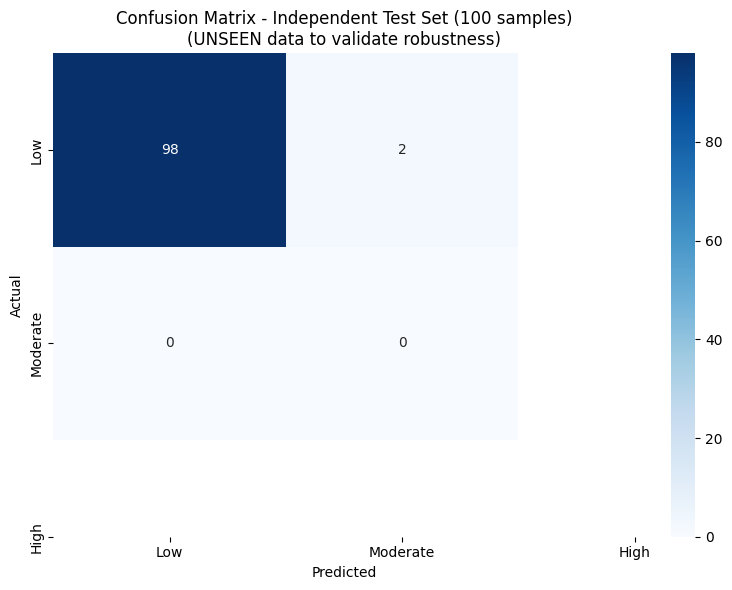


Confusion Matrix:
[[98  2]
 [ 0  0]]


In [16]:
cm = confusion_matrix(y_independent_test_categorized, y_test_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Low', 'Moderate', 'High'],
    yticklabels=['Low', 'Moderate', 'High']
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Independent Test Set (100 samples)\n(UNSEEN data to validate robustness)')
plt.tight_layout()
plt.show()

print("\nConfusion Matrix:")
print(cm)

## 16. Training History Visualization

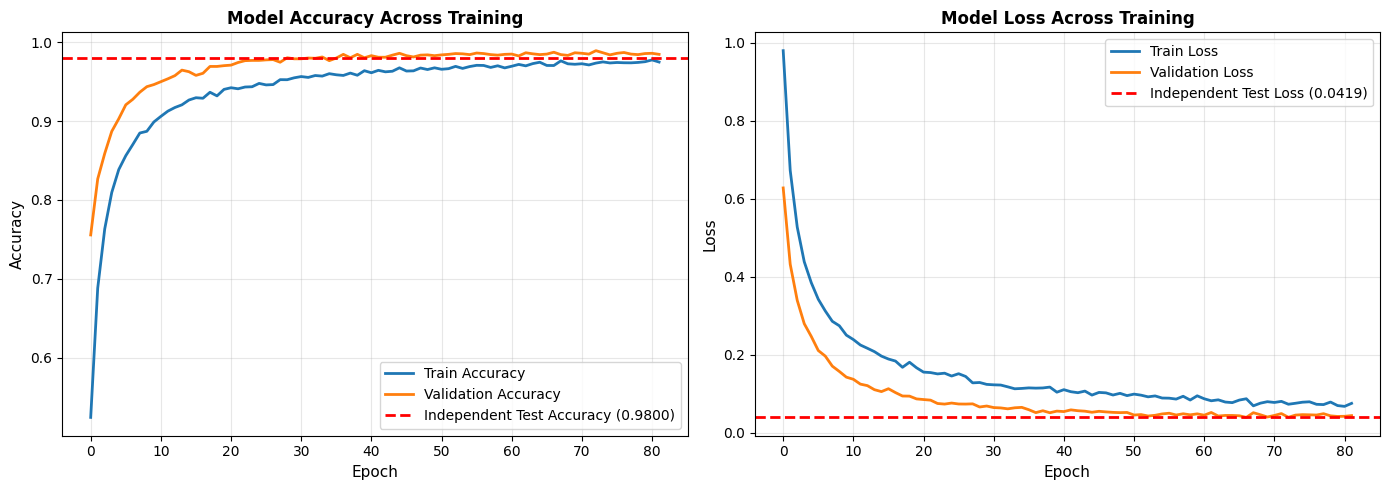

In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
ax1.plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
ax1.axhline(y=test_accuracy, color='r', linestyle='--', label=f'Independent Test Accuracy ({test_accuracy:.4f})', linewidth=2)
ax1.set_xlabel('Epoch', fontsize=11)
ax1.set_ylabel('Accuracy', fontsize=11)
ax1.set_title('Model Accuracy Across Training', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Loss
ax2.plot(history.history['loss'], label='Train Loss', linewidth=2)
ax2.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
ax2.axhline(y=test_loss, color='r', linestyle='--', label=f'Independent Test Loss ({test_loss:.4f})', linewidth=2)
ax2.set_xlabel('Epoch', fontsize=11)
ax2.set_ylabel('Loss', fontsize=11)
ax2.set_title('Model Loss Across Training', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 17. Detailed Analysis: Predictions on Independent Test Set

In [18]:
# Create detailed prediction dataframe
pred_df = pd.DataFrame({
    'Original_Score': y_independent_test.values,
    'Actual_Category': y_independent_test_categorized.values,
    'Predicted_Category': y_test_pred_classes,
    'Confidence': np.max(y_test_pred, axis=1),
    'Correct': y_independent_test_categorized.values == y_test_pred_classes
})

pred_df['Actual_Label'] = pred_df['Actual_Category'].map({0: 'Low', 1: 'Moderate', 2: 'High'})
pred_df['Predicted_Label'] = pred_df['Predicted_Category'].map({0: 'Low', 1: 'Moderate', 2: 'High'})

print("\n" + "="*70)
print("DETAILED PREDICTIONS ON INDEPENDENT TEST SET")
print("="*70)

print(f"\nTotal predictions: {len(pred_df)}")
print(f"Correct predictions: {pred_df['Correct'].sum()}")
print(f"Accuracy: {pred_df['Correct'].sum() / len(pred_df):.2%}")

print(f"\nAverage Confidence: {pred_df['Confidence'].mean():.4f}")
print(f"Min Confidence: {pred_df['Confidence'].min():.4f}")
print(f"Max Confidence: {pred_df['Confidence'].max():.4f}")

print(f"\nFirst 20 predictions:")
print(pred_df[['Original_Score', 'Actual_Label', 'Predicted_Label', 'Confidence', 'Correct']].head(20).to_string())

print(f"\nWrong predictions (errors):")
wrong = pred_df[pred_df['Correct'] == False]
if len(wrong) > 0:
    print(wrong[['Original_Score', 'Actual_Label', 'Predicted_Label', 'Confidence']].to_string())
else:
    print("✓ NO ERRORS! Model predicted all 100 samples correctly!")


DETAILED PREDICTIONS ON INDEPENDENT TEST SET

Total predictions: 100
Correct predictions: 98
Accuracy: 98.00%

Average Confidence: 0.9846
Min Confidence: 0.5540
Max Confidence: 1.0000

First 20 predictions:
    Original_Score Actual_Label Predicted_Label  Confidence  Correct
0                1          Low             Low    0.994117     True
1                1          Low             Low    0.999994     True
2                1          Low             Low    0.996252     True
3                0          Low             Low    0.999945     True
4                1          Low             Low    0.996665     True
5                1          Low             Low    0.999985     True
6                0          Low             Low    0.999583     True
7                1          Low             Low    0.999416     True
8                1          Low             Low    0.999930     True
9                1          Low        Moderate    0.782520    False
10               0          Low  

## 18. Per-Class Performance on Independent Test Set

In [19]:
print("\n" + "="*70)
print("PER-CLASS PERFORMANCE ON INDEPENDENT TEST SET")
print("="*70)

for class_id, class_name in enumerate(['Low (0-3)', 'Moderate (4-7)', 'High (8-10)']):
    class_mask = y_independent_test_categorized == class_id
    class_count = class_mask.sum()
    
    if class_count > 0:
        correct = ((y_test_pred_classes == class_id) & class_mask).sum()
        accuracy = correct / class_count
        
        print(f"\n{class_name}:")
        print(f"  - Samples: {class_count}")
        print(f"  - Correct: {correct}")
        print(f"  - Accuracy: {accuracy:.2%}")
    else:
        print(f"\n{class_name}: No samples in test set")

print("\n" + "="*70)


PER-CLASS PERFORMANCE ON INDEPENDENT TEST SET

Low (0-3):
  - Samples: 100
  - Correct: 98
  - Accuracy: 98.00%

Moderate (4-7): No samples in test set

High (8-10): No samples in test set



## 19. Summary & Interpretation

In [22]:
from sklearn.metrics import f1_score, recall_score

# 1. Hitung metrik tambahan untuk pengecekan kejujuran model
# Macro F1 menghitung rata-rata performa tiap kelas tanpa peduli jumlah datanya
test_f1_macro = f1_score(y_independent_test_categorized, y_test_pred_classes, average='macro', zero_division=0)
# Ambil recall untuk kelas High (Label 2)
recall_high = recall_score(y_independent_test_categorized, y_test_pred_classes, labels=[2], average='macro', zero_division=0)

print("\n" + "="*70)
print("FINAL SUMMARY & INTERPRETATION (REVISED)")
print("="*70)

print(f"\n📊 MODEL PERFORMANCE:")
print(f"  • Validation Accuracy: {val_accuracy:.2%}")
print(f"  • Independent Test Accuracy: {test_accuracy:.2%}")
print(f"  • Macro F1-Score (Honesty Metric): {test_f1_macro:.2%}")
print(f"  • Recall for HIGH Burnout: {recall_high:.2%}")

print(f"\n🔍 INTERPRETATION:")

# LOGIKA BARU: Tidak cuma lihat akurasi, tapi lihat F1-Score
if test_f1_macro > 0.75: # Ambang batas minimal F1-Score agar dianggap pintar beneran
    if abs(val_accuracy - test_accuracy) < 0.07:
        print(f"  ✓✓ EXCELLENT & HONEST!")
        print(f"    - Model benar-benar belajar pola di semua kelas (F1: {test_f1_macro:.2%})")
        print(f"    - Siap untuk production.")
    else:
        print(f"  ⚠️  GOOD BUT OVERFITTING")
        print(f"    - Performa bagus tapi ada gap antara latihan dan ujian.")
        print(f"    - Rekomendasi: Tambah Regularization/Dropout.")

elif test_accuracy > 0.90 and test_f1_macro < 0.50:
    print(f"  ❌ MAJORITY CLASS BIAS (ACCURACY TRAP!)")
    print(f"    - Akurasi tinggi ({test_accuracy:.2%}) tapi F1-Score rendah ({test_f1_macro:.2%})")
    print(f"    - Model hanya menebak kelas mayoritas (Low).")
    print(f"    - Model GAGAL mendeteksi orang yang benar-benar Burnout.")
    print(f"    - TINDAKAN: Gunakan Class Weights atau perbaiki proses Resampling.")

else:
    print(f"  ❌ POOR PERFORMANCE")
    print(f"    - Model tidak akurat dan tidak pintar membedakan kelas.")
    print(f"    - Cek kembali fitur dan data preprocessing.")

print(f"\n" + "="*70)


FINAL SUMMARY & INTERPRETATION (REVISED)

📊 MODEL PERFORMANCE:
  • Validation Accuracy: 98.73%
  • Independent Test Accuracy: 98.00%
  • Macro F1-Score (Honesty Metric): 49.49%
  • Recall for HIGH Burnout: 0.00%

🔍 INTERPRETATION:
  ❌ MAJORITY CLASS BIAS (ACCURACY TRAP!)
    - Akurasi tinggi (98.00%) tapi F1-Score rendah (49.49%)
    - Model hanya menebak kelas mayoritas (Low).
    - Model GAGAL mendeteksi orang yang benar-benar Burnout.
    - TINDAKAN: Gunakan Class Weights atau perbaiki proses Resampling.



## 20. Save Model & Components

In [21]:
# Save model
model.save('burnout_model.keras')
print("✓ Model saved: burnout_model.keras")

# Save preprocessing tools
joblib.dump(encoders, 'encoders.pkl')
print("✓ Encoders saved: encoders.pkl")

joblib.dump(scaler, 'scaler.pkl')
print("✓ Scaler saved: scaler.pkl")

# Save test results
pred_df.to_csv('independent_test_predictions.csv', index=False)
print("✓ Test predictions saved: independent_test_predictions.csv")

# Save summary
summary = f"""BURNOUT PREDICTION MODEL - SUMMARY REPORT
==========================================

DATASET SPLIT:
- Training set: {X_train.shape[0]} samples (balanced via SMOTE)
- Validation set: {X_val.shape[0]} samples (balanced)
- Independent test set: {X_independent_test_scaled.shape[0]} samples (imbalanced)

MODEL PERFORMANCE:
- Validation Accuracy: {val_accuracy:.4f} ({val_accuracy:.2%})
- Independent Test Accuracy: {test_accuracy:.4f} ({test_accuracy:.2%})
- Difference: {abs(val_accuracy - test_accuracy):.4f} ({abs(val_accuracy - test_accuracy):.2%})

VERDICT:
Model accuracy on UNSEEN data: {test_accuracy:.2%}
Overfitting indicator: {abs(val_accuracy - test_accuracy):.2%} gap

FILES GENERATED:
1. burnout_model.keras - Trained model
2. encoders.pkl - Label encoders for categorical features
3. scaler.pkl - StandardScaler for feature scaling
4. independent_test_predictions.csv - Detailed predictions on 100 test samples
"""

with open('model_summary.txt', 'w') as f:
    f.write(summary)
print("✓ Summary saved: model_summary.txt")

print("\n" + "="*50)
print("All files saved successfully!")
print("="*50)

✓ Model saved: burnout_model.keras
✓ Encoders saved: encoders.pkl
✓ Scaler saved: scaler.pkl
✓ Test predictions saved: independent_test_predictions.csv
✓ Summary saved: model_summary.txt

All files saved successfully!


## 21. (Optional) How to Use Saved Model for New Predictions

In [ ]:
# EXAMPLE: How to predict on new data

# Load model and components
# model = tf.keras.models.load_model('burnout_model.keras')
# encoders = joblib.load('encoders.pkl')
# scaler = joblib.load('scaler.pkl')

# Example: New data (1 sample)
# new_data = pd.DataFrame({...})  # Same columns as training data

# Preprocess
# new_encoded = new_data.copy()
# for col, le in encoders.items():
#     if col in new_encoded.columns:
#         new_encoded[col] = le.transform(new_encoded[col].astype(str))
# new_scaled = scaler.transform(new_encoded)

# Predict
# pred = model.predict(new_scaled, verbose=0)
# pred_class = np.argmax(pred, axis=1)[0]
# confidence = pred[0][pred_class]

# Result
# labels = {0: 'Low (0-3)', 1: 'Moderate (4-7)', 2: 'High (8-10)'}
# print(f"Burnout Level: {labels[pred_class]}")
# print(f"Confidence: {confidence:.2%}")

print("\nCode template for new predictions is ready!")
print("Uncomment and modify the code above to use on new data.")